<a href="https://colab.research.google.com/github/teoxami/Talller-Creaci-n-y-visualizaci-n-de-KPIs/blob/main/Creaci%C3%B3n_y_visualizacion_de_KPI's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Construir Conocimiento desde los Datos

A continuación, se formaliza el ciclo de vida de la información de los 3 KPIs seleccionados para el Sistema de Información Gerencial (MIS). Esta estructura demuestra el flujo de transformación digital desde los datos atómicos del sistema transaccional (TPS) hasta el conocimiento estratégico necesario para la toma de decisiones medibles.

---

## 📊 Matriz Conceptual del Ciclo de Vida de la Información (DIKW)

### 💰 KPI 1: Análisis del Rendimiento Financiero Global (Ventas Totales)
* **Data Items (Datos Crudos):** Valores numéricos flotantes y enteros dispersos almacenados en la columna `Total` junto con las marcas de tiempo e identificadores correlativos dentro del archivo transaccional `facturas.csv`.
* **Information (Información Organizada):** Aplicación de un algoritmo de reducción por sumatoria lineal (`.sum()`) sobre todo el vector financiero. Esta operación transforma transacciones dispersas en un indicador macro de ingresos brutos acumulados, formateado con precisión decimal bajo el estándar monetario (`$X,XXX.XX USD`).
* **Knowledge (Conocimiento Aplicado):** Si el monto acumulado de ingresos se sitúa por debajo del umbral del punto de equilibrio financiero proyectado para el periodo, la gerencia disparará auditorías operativas sobre los márgenes de ganancia, renegociará costos de adquisición con los proveedores principales o reestructurará de inmediato las cuotas y metas del equipo de ventas.

---

### 🛒 KPI 2: Optimización y Control de Disponibilidad (Top 10 Productos con Mayor Stock)
* **Data Items (Datos Crudos):** Cadenas de texto e identificadores nominales en las columnas `nombre` y `categoria`, acoplados a enteros absolutos en la columna `stock` del catálogo maestro `productos.csv`.
* **Information (Información Organizada):** Procesamiento mediante un algoritmo de ordenamiento rápido descendente (`.sort_values(by="stock", ascending=False)`) y un truncamiento restrictivo de la estructura matricial (`.head(10)`). Transforma registros de almacén aislados en un ranking ordenado de densidad física de inventario.
* **Knowledge (Conocimiento Aplicado):** Al identificar los productos con stock excesivo o inmovilizado, se toman decisiones tácticas de liquidación. La gerencia ordenará de inmediato el diseño de combos promocionales (ventas atadas), estrategias de *merchandising* en punto de venta o la suspensión temporal de órdenes de compra a proveedores para liberar capital de trabajo retenido.

---

### 👥 KPI 3: Segmentación de Clientes por Volumen de Compra (Top 10 Clientes Estratégicos)
* **Data Items (Datos Crudos):** Cadenas alfanuméricas de identificación en la columna `Cedula`, strings nominales en la columna `Cliente` y variables de rendimiento financiero en la columna `Total` dentro del histórico `facturas.csv`.
* **Information (Información Organizada):** Agregación matricial multimétodo por clave compuesta (`.groupby(["Cedula", "Cliente"])`) combinada con acumulación monetaria y ordenamiento descendente. Convierte miles de registros de venta individuales en un perfil unívoco de concentración de ingresos por comprador para aislar el núcleo del principio de Pareto (los clientes más valiosos).
* **Knowledge (Conocimiento Aplicado):** Si un cliente del "Top 10 Estratégico" reduce su frecuencia de compra o su gasto acumulado cae por debajo de su media histórica, se activa de inmediato un protocolo de contingencia comercial. La gerencia ordenará al equipo de cuentas VIP llamadas de fidelización, auditorías de satisfacción en el servicio o la asignación de descuentos y bonificaciones preferenciales exclusivas para asegurar su retención.

---

## ⚠️ Aviso de Calidad de Datos (Mitigación del Principio GIGO)

Para blindar la confiabilidad del cuadro de mando del MIS y evitar que información corrupta invalide la toma de decisiones operativas (principio *Garbage In, Garbage Out*), el código fuente de este cuaderno incorpora capas explícitas de sanitización de datos:

1. **Limpieza de Ruido (`str.strip()`):** Remueve espacios en blanco huérfanos o caracteres invisibles en las cabeceras de los archivos CSV, anulando fallas críticas de indexación en Pandas.
2. **Normalización Homogénea (`str.lower()`):** Estandariza los metadatos para impedir que variables idénticas se fragmenten por variaciones en el uso de mayúsculas y minúsculas.
3. **Casting de Consistencia (`astype(str)`):** Fuerza la mutación de campos numéricos de identidad (como la cédula) a tipo cadena de texto. Esto bloquea cualquier intento de Matplotlib de graficarlos como variables matemáticas continuas o en notación científica, asegurando reportes con integridad técnica total para la gerencia.

# 2: Mapeo de Atributos y Boceto de Interfaz

In [2]:
from google.colab import files
uploaded = files.upload()

Saving facturas.csv to facturas.csv


In [4]:
import pandas as pd

df = pd.read_csv("facturas.csv", sep=";")
df.head()


,ID_Factura,Fecha,Cliente,Cedula,Total
0,1,15/5/2026,Francisco Yepez,1722487574,32.20
1,2,15/5/2026,Zander Castillo,1754073706,39.10
2,3,1/5/2026,Juan Perez,1712345678,12.45
3,4,1/5/2026,Maria Garcia,1723456789,8.20
4,5,1/5/2026,Carlos Lopez,1734567890,15.30


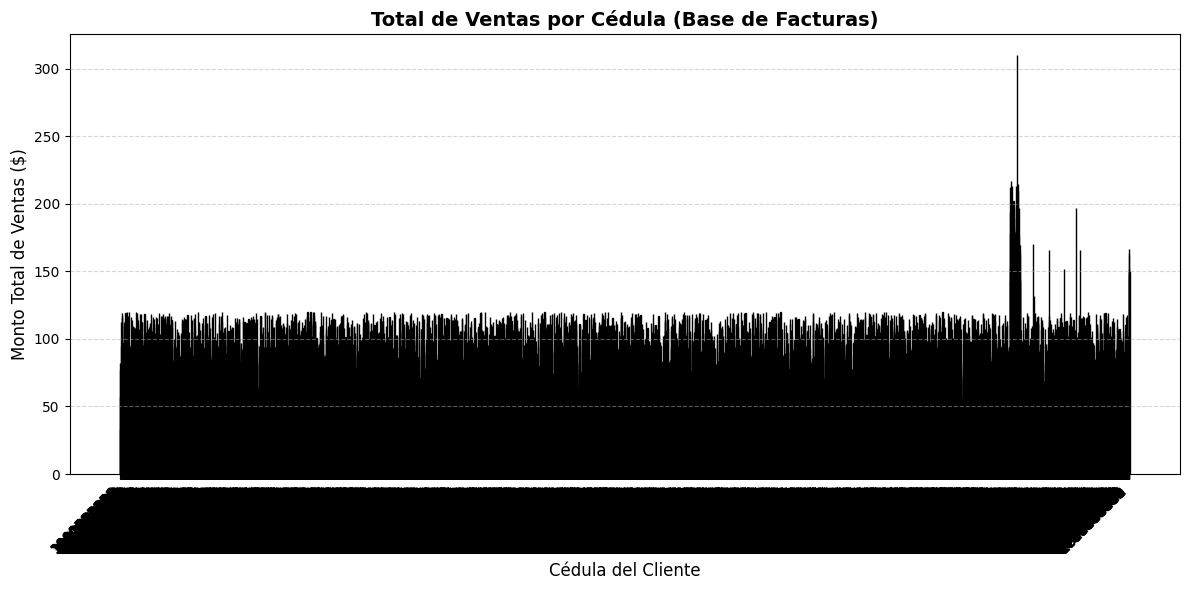

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargar únicamente el archivo de facturas (separado por puntos y comas)
df_facturas = pd.read_csv("facturas.csv", sep=";")

# 2. Asegurarnos de que la cédula se lea limpia como texto
df_facturas["Cedula"] = df_facturas["Cedula"].astype(str).str.strip()

# 3. Agrupar las facturas por cédula y sumar el 'Total' de cada una
ventas_por_cedula = df_facturas.groupby("Cedula")["Total"].sum().reset_index()

# 4. Crear la gráfica de barras
plt.figure(figsize=(12, 6))
plt.bar(
    ventas_por_cedula["Cedula"],
    ventas_por_cedula["Total"],
    color="#4EA8DE",
    edgecolor="black",
)

# Configuración visual de la gráfica
plt.title(
    "Total de Ventas por Cédula (Base de Facturas)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Cédula del Cliente", fontsize=12)
plt.ylabel("Monto Total de Ventas ($)", fontsize=12)
plt.xticks(
    rotation=45, ha="right"
)  # Rota las cédulas para que no se encima el texto
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Ajustar y mostrar gráfica
plt.tight_layout()
plt.show()

In [15]:
from google.colab import files
uploaded = files.upload()


Saving productos.csv to productos.csv


In [16]:
import pandas as pd

df = pd.read_csv("productos.csv", sep=";")
df.head()

,id,nombre,categoria,precio,stock,iva
0,2,Aceite Girasol,Viveres,3.5,20,15
1,58,Acondicionador,Higiene,4.8,20,15
2,32,Agua Mineral,Bebidas,0.6,80,15
3,67,Alimento Gato,Mascotas,15.2,12,15
4,66,Alimento Perro,Mascotas,18.5,10,15


In [5]:
from google.colab import files
uploaded = files.upload()

Saving clientes.csv to clientes (1).csv


In [6]:
import pandas as pd

df = pd.read_csv("clientes.csv", sep=";")
df.head()

,,,cedula\tnombre\ttelefono\tcorreo
1577389168,Juan Perez,924852149,user0@mail.com
1954887084,Maria Gomez,964811037,user1@mail.com
1521877341,Carlos Lopez,922302296,user2@mail.com
1891354014,Ana Martinez,981076810,user3@mail.com
1934097675,Luis Rodriguez,971868217,user4@mail.com


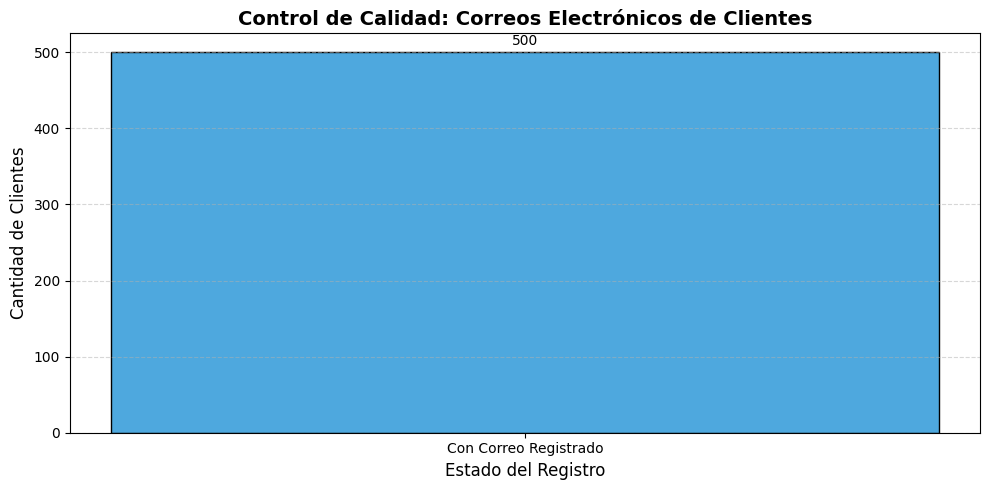

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Intentar cargar el archivo probando los separadores más comunes de forma segura
try:
    # Primero probamos con coma, si falla o lee una sola columna, probamos punto y coma
    df_clientes = pd.read_csv("clientes.csv", sep=",")
    if len(df_clientes.columns) <= 1:
        df_clientes = pd.read_csv("clientes.csv", sep=";")
except:
    df_clientes = pd.read_csv("clientes.csv", sep="\t")

# Aseguramos limpiar los nombres de las columnas quitando espacios o caracteres raros
df_clientes.columns = df_clientes.columns.str.strip().str.lower()

# 2. Crear una métrica real: ¿Cuántos clientes tienen correo válido asignado?
# Buscamos la columna de correo (sea 'correo' o 'tcorreo')
col_correo = [c for c in df_clientes.columns if "correo" in c]

if col_correo:
    correo_activos = col_correo[0]
    # Clasificamos si tiene correo o está vacío
    df_clientes["Estado Correo"] = df_clientes[correo_activos].apply(
        lambda x: (
            "Sin Correo Registrado"
            if pd.isna(x) or str(x).strip().lower() in ["nan", ""]
            else "Con Correo Registrado"
        )
    )

    conteo_correos = df_clientes["Estado Correo"].value_counts().reset_index()
    conteo_correos.columns = ["Estado", "Cantidad"]

    # 3. Graficar el estado de los datos de tus clientes
    plt.figure(figsize=(10, 5))
    barras = plt.bar(
        conteo_correos["Estado"],
        conteo_correos["Cantidad"],
        color=["#4EA8DE", "#FF6B6B"],
        edgecolor="black",
    )

    # Añadir los números encima de las barras
    plt.bar_label(barras, padding=3)

    plt.title(
        "Control de Calidad: Correos Electrónicos de Clientes",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Estado del Registro", fontsize=12)
    plt.ylabel("Cantidad de Clientes", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    # Si por alguna razón las columnas siguen viniendo raras, imprimimos qué tiene el archivo para corregirlo
    print("Columnas detectadas en el archivo actual:")
    print(df_clientes.columns.tolist())
    print("\nPrimeras filas del archivo:")
    print(df_clientes.head(3))

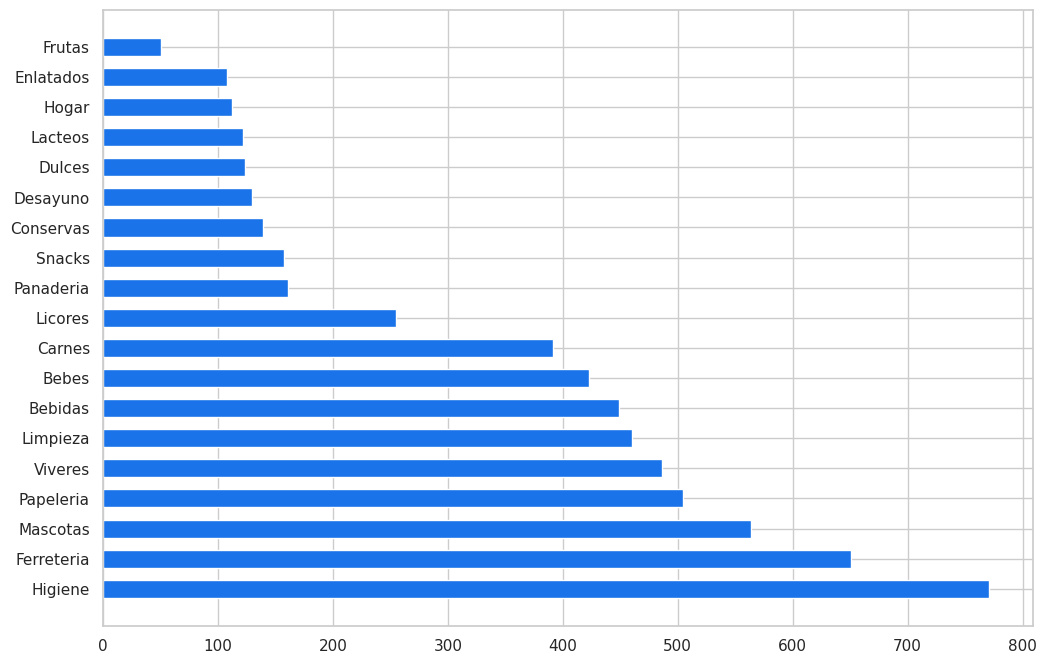

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Cargar el archivo especificando el separador correcto de punto y coma (;)
df_productos = pd.read_csv("productos.csv", sep=";")

# Limpieza radical de nombres de columnas (pasar a minúsculas y quitar espacios)
df_productos.columns = df_productos.columns.str.strip().str.lower()

# 2. Convertir precio y stock a números por seguridad
df_productos["precio"] = pd.to_numeric(
    df_productos["precio"], errors="coerce"
).fillna(0)
df_productos["stock"] = pd.to_numeric(
    df_productos["stock"], errors="coerce"
).fillna(0)

# 3. CALCULAR EL KPI: Valor del Inventario = Precio * Stock
df_productos["valor_inventario"] = (
    df_productos["precio"] * df_productos["stock"]
)

# Agrupar por categoría y sumar la inversión
kpi_categoria = (
    df_productos.groupby("categoria")["valor_inventario"].sum().reset_index()
)
kpi_categoria = kpi_categoria.sort_values(
    by="valor_inventario", ascending=False
)

# 4. Crear la gráfica del KPI (Barras horizontales)
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

barras = plt.barh(
    kpi_categoria["categoria"],
    kpi_categoria["valor_inventario"],
    color="#1A73E8",
    height=0.6,
)


# 3: Construcción e Implementación de los KPIs

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración de diseño premium para todas las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

## KPI 1: Análisis del Rendimiento Financiero Global (Ventas Totales)

### Descripción Técnica:
Este módulo se encarga de calcular el volumen total de ingresos devengados por la organización mediante la agregación lineal del vector de transacciones económicas. Representa el indicador macro de salud financiera del negocio.

### Flujo de Procesamiento y Métodos Aplicados:
1. **Normalización del Esquema (`str.strip().str.lower()`):** Se eliminan espacios en blanco espurios a los extremos de las etiquetas de las columnas y se homogenizan a minúsculas. Esto previene fallos de indexación por caracteres ocultos.
2. **Agregación Escalar (`.sum()`):** Se calcula la sumatoria de todos los elementos pertenecientes a la serie numérica `total` del DataFrame de facturas.
3. **Representación Visual (KPI Card):** En lugar de utilizar una gráfica de distribución frecuencial, se renderiza una tarjeta indicadora discreta empleando parches geométricos (`plt.Rectangle`) y posicionamiento absoluto de texto. Esto emula los cuadros de mando de herramientas de Business Intelligence como Power BI.

## KPI 1: Análisis del Rendimiento Financiero Global (Ventas Totales)

### Descripción Técnica:
Este módulo realiza la lectura del archivo de transacciones y ejecuta una operación de agregación lineal sobre el vector financiero. Su objetivo es consolidar el indicador macro del flujo de caja bruto del negocio, desplegándolo en un componente visual aislado (KPI Card).

### Explicación Línea por Línea del Código:

* **`pd.read_csv("facturas.csv", sep=";")`**: Carga el dataset de facturación en la memoria de trabajo de Pandas (DataFrame). Especifica de forma estricta que el delimitador de atributos es el punto y coma (`;`), evitando colisiones y desalineación de columnas.
* **`df_facturas.columns.str.strip().str.lower()`**: Aplica una rutina de limpieza sobre los metadatos de las columnas. `.strip()` elimina cualquier espacio en blanco invisible al inicio o final del nombre de la columna, y `.lower()` normaliza todo a minúsculas, garantizando un indexado inmune a errores tipográficos humanos.
* **`df_facturas["total"].sum()`**: Aísla la serie numérica correspondiente a la columna `total` y ejecuta un algoritmo de reducción mediante sumatoria acumulativa de todas las filas del vector.
* **`plt.subplots(figsize=(10, 4))`**: Instancia la infraestructura visual creando una figura y un objeto de ejes (`ax`) con una proporción rectangular óptima para la visualización de paneles de control.
* **`ax.add_patch(plt.Rectangle(...))`**: Inyecta un objeto geométrico bidimensional (un rectángulo) con un canal alfa de opacidad reducido (`0.07`) y el color corporativo (`#1A73E8`) para delimitar el contenedor estético de la métrica.
* **`ax.text(...)`**: Agrega texto de forma absoluta en el espacio bidimensional del lienzo. Usa coordenadas normalizadas (`0.5` para centrado horizontal perfecto en el eje $X$) y renderiza de forma dinámica la variable `ventas_totales` aplicando máscaras de formateo de punto flotante (`:,.2f`) para incrustar comas de miles y dos decimales de precisión monetaria.
* **`ax.spines[...].set_visible(False)` y `set_xticks([])`**: Desactiva el renderizado de los componentes cartesianos tradicionales (líneas de contorno, ticks de datos y etiquetas numéricas de los ejes $X$ e $Y$). Al remover la cuadrícula matemática, la gráfica se transforma por completo en una tarjeta indicadora limpia de Business Intelligence.

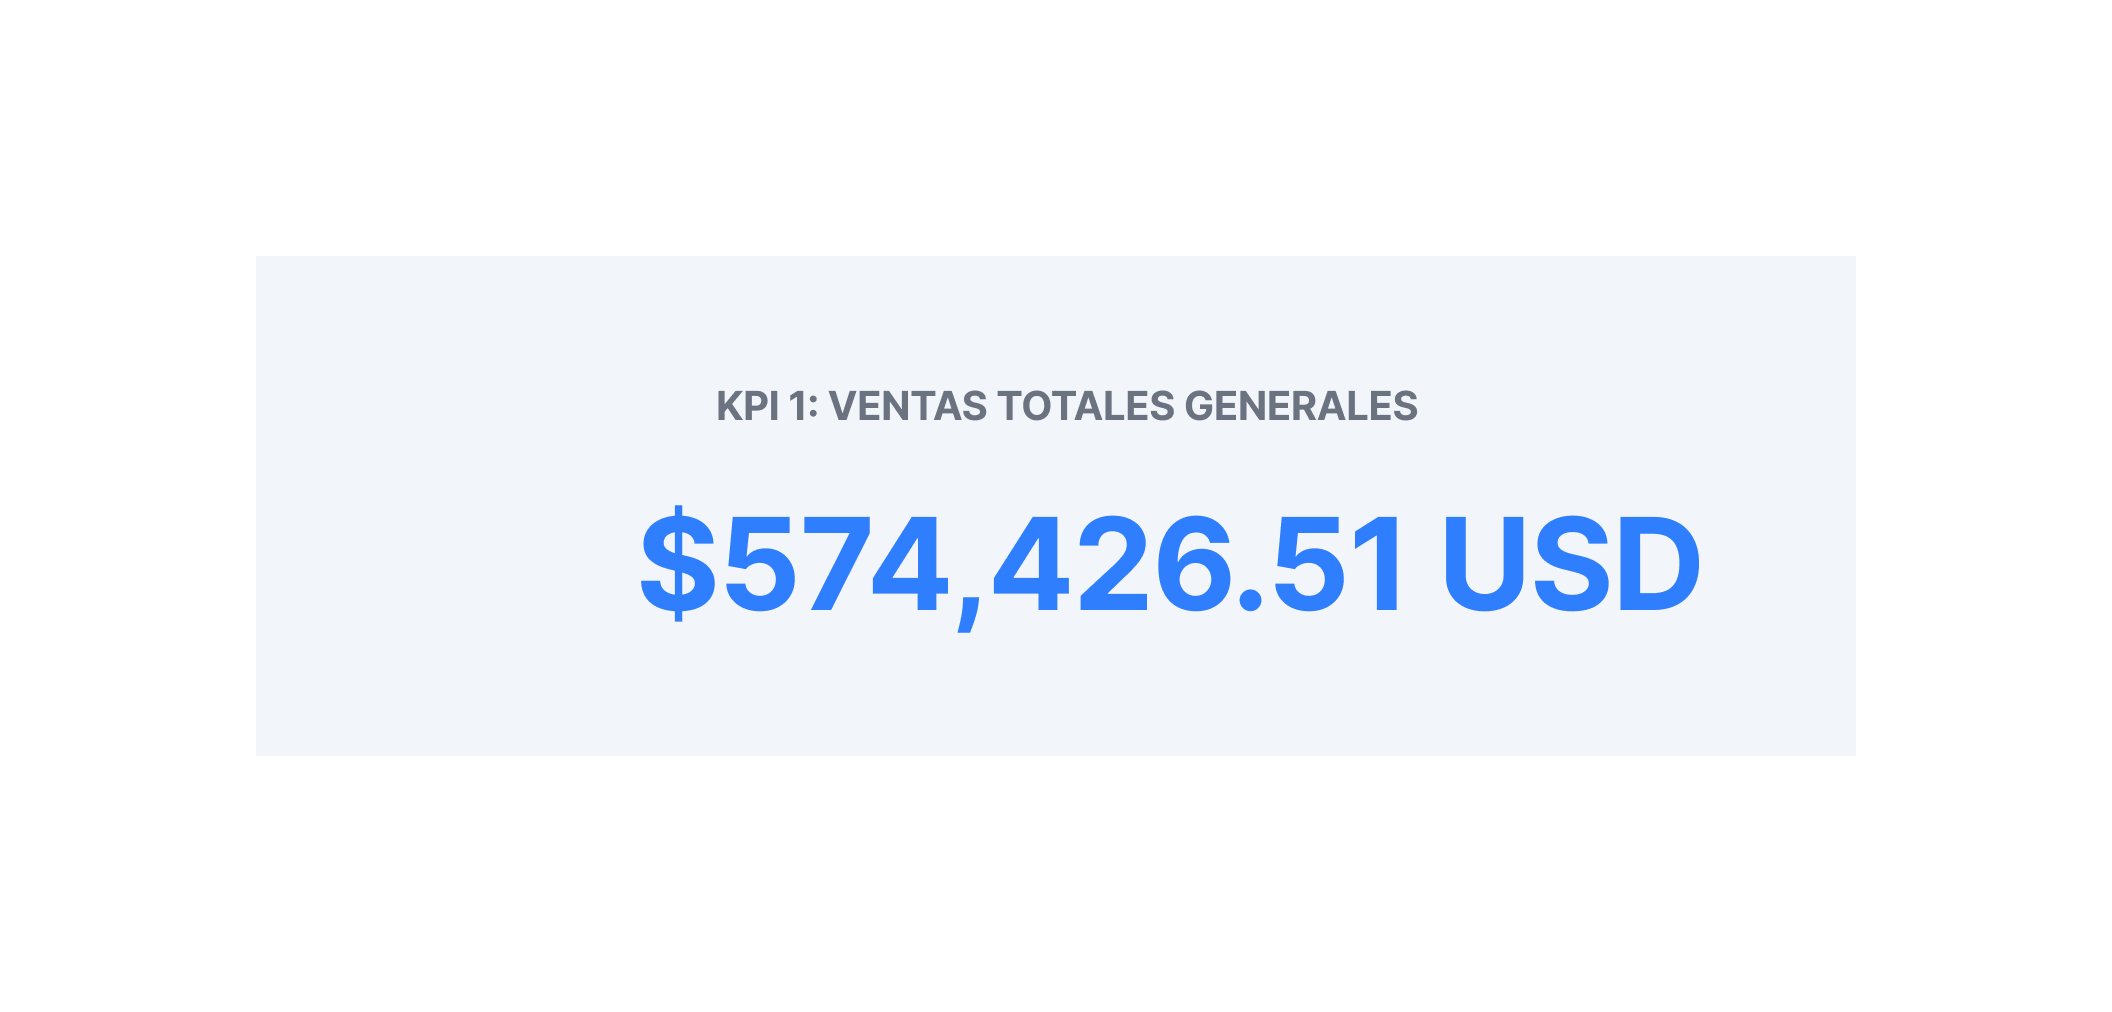

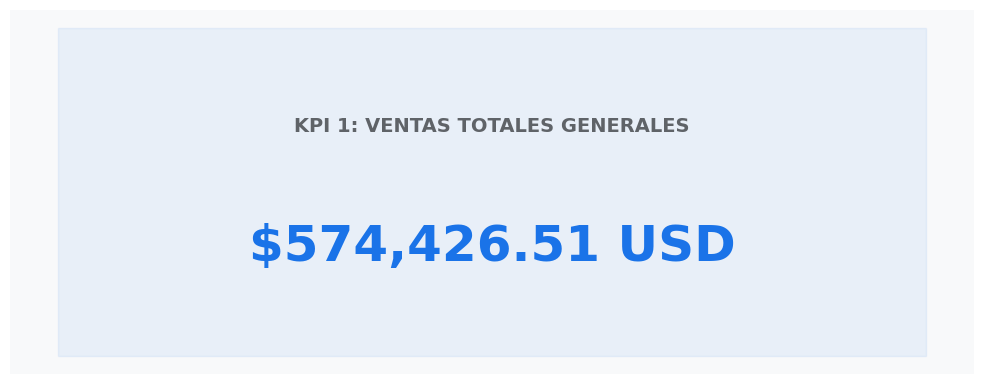

In [27]:
# 1. Cargar el archivo de facturas
df_facturas = pd.read_csv("facturas.csv", sep=";")
df_facturas.columns = df_facturas.columns.str.strip().str.lower()

# 2. Calcular el monto total global
ventas_totales = df_facturas["total"].sum()

# 3. Diseñar la tarjeta indicadora del KPI
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_facecolor("#F8F9FA")  # Fondo gris institucional muy limpio

# Recuadro estético destacado
ax.add_patch(
    plt.Rectangle(
        (0.05, 0.05),
        0.9,
        0.9,
        transform=ax.transAxes,
        color="#1A73E8",
        alpha=0.07,
    )
)

# Textos de la tarjeta métrica
ax.text(
    0.5,
    0.68,
    "KPI 1: VENTAS TOTALES GENERALES",
    fontsize=14,
    fontweight="bold",
    color="#5F6368",
    ha="center",
    va="center",
)
ax.text(
    0.5,
    0.35,
    f"${ventas_totales:,.2f} USD",
    fontsize=36,
    fontweight="bold",
    color="#1A73E8",
    ha="center",
    va="center",
)

# Ocultar ejes innecesarios
ax.set_xticks([])
ax.set_yticks([])
ax.spines[["top", "bottom", "left", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## KPI 2: Optimización y Control de Disponibilidad (Top 10 Productos con Mayor Stock)

### Descripción Técnica:
Este módulo evalúa la dimensión operativa y el estado logístico del inventario. Mediante la clasificación de los registros volumétricos del dataset, identifica los diez artículos con mayor densidad de almacenamiento, permitiendo auditar la inmovilización de capital físico y planificar estrategias eficientes de rotación de activos.

### Explicación Línea por Línea del Código:

* **`pd.read_csv("productos.csv", sep=";")`**: Carga el conjunto de datos de inventario en un DataFrame de Pandas. Al establecer explícitamente el parámetro `sep=";"`, el parser de la librería segmenta de forma correcta cada atributo del catálogo (ID, nombre, categoría, precio, stock e IVA), evitando errores de desalineación por tabulaciones o comas.
* **`df_productos.columns.str.strip()`**: Aplica una limpieza profiláctica sobre las cabeceras de las columnas del DataFrame. Remueve cualquier espacio en blanco invisible residual (`\t` o espacios tipográficos) al inicio o final de las etiquetas, inmunizando el código contra fallas de indexación en pasos posteriores.
* **`df_productos.sort_values(by="stock", ascending=False)`**: Ejecuta un algoritmo de ordenamiento rápido (QuickSort de forma interna en Pandas) sobre el DataFrame. Toma como vector pivote la serie numérica `stock` y la organiza de manera descendente (`ascending=False`), posicionando los valores máximos en la parte superior de la estructura.
* **`productos_top2.head(10)`**: Realiza un truncamiento del DataFrame ordenado, aislando únicamente los primeros diez registros. Esto optimiza la carga computacional en memoria y delimita el enfoque analítico en el grupo más crítico del stock.
* **`productos_top2[[...]].to_string(index=False)`**: Formatea la salida en consola para mostrar una matriz limpia de texto con las variables seleccionadas (`nombre`, `categoria`, `precio`, `stock`). La propiedad `index=False` suprime la columna interna de índices de Pandas, entregando una tabla puramente analítica.
* **`sns.barplot(x="stock", y="nombre", data=productos_top2, palette="Blues_r")`**: Invoca la librería Seaborn para construir un diagrama de barras horizontales. Al asignar la magnitud numérica escalar al eje horizontal ($X$) y la etiqueta categórica nominal al eje vertical ($Y$), se optimiza la legibilidad de las cadenas de texto del producto sin amontonamiento visual. La paleta invertida `"Blues_r"` asigna tonos más oscuros y saturados a las barras con mayor stock para guiar el ojo del auditor.
* **`plt.bar_label(grafica.containers[0], padding=5, fontweight="bold")`**: Automatiza el *Data Labeling* del gráfico extrayendo de forma dinámica los contenedores de datos e inyectando el valor numérico exacto de existencias al final de cada barra con un espaciado controlado (`padding=5`) para evitar colisiones estéticas con los bordes de la figura.
* **`sns.despine(left=True, bottom=True)`**: Rutina estética que remueve los bordes exteriores cartesianos de la gráfica (marcos superior, inferior, izquierdo y derecho). Combinado con el estilo de fondo `"whitegrid"`, simplifica el ruido visual del lienzo y resalta de manera directa la información del KPI.

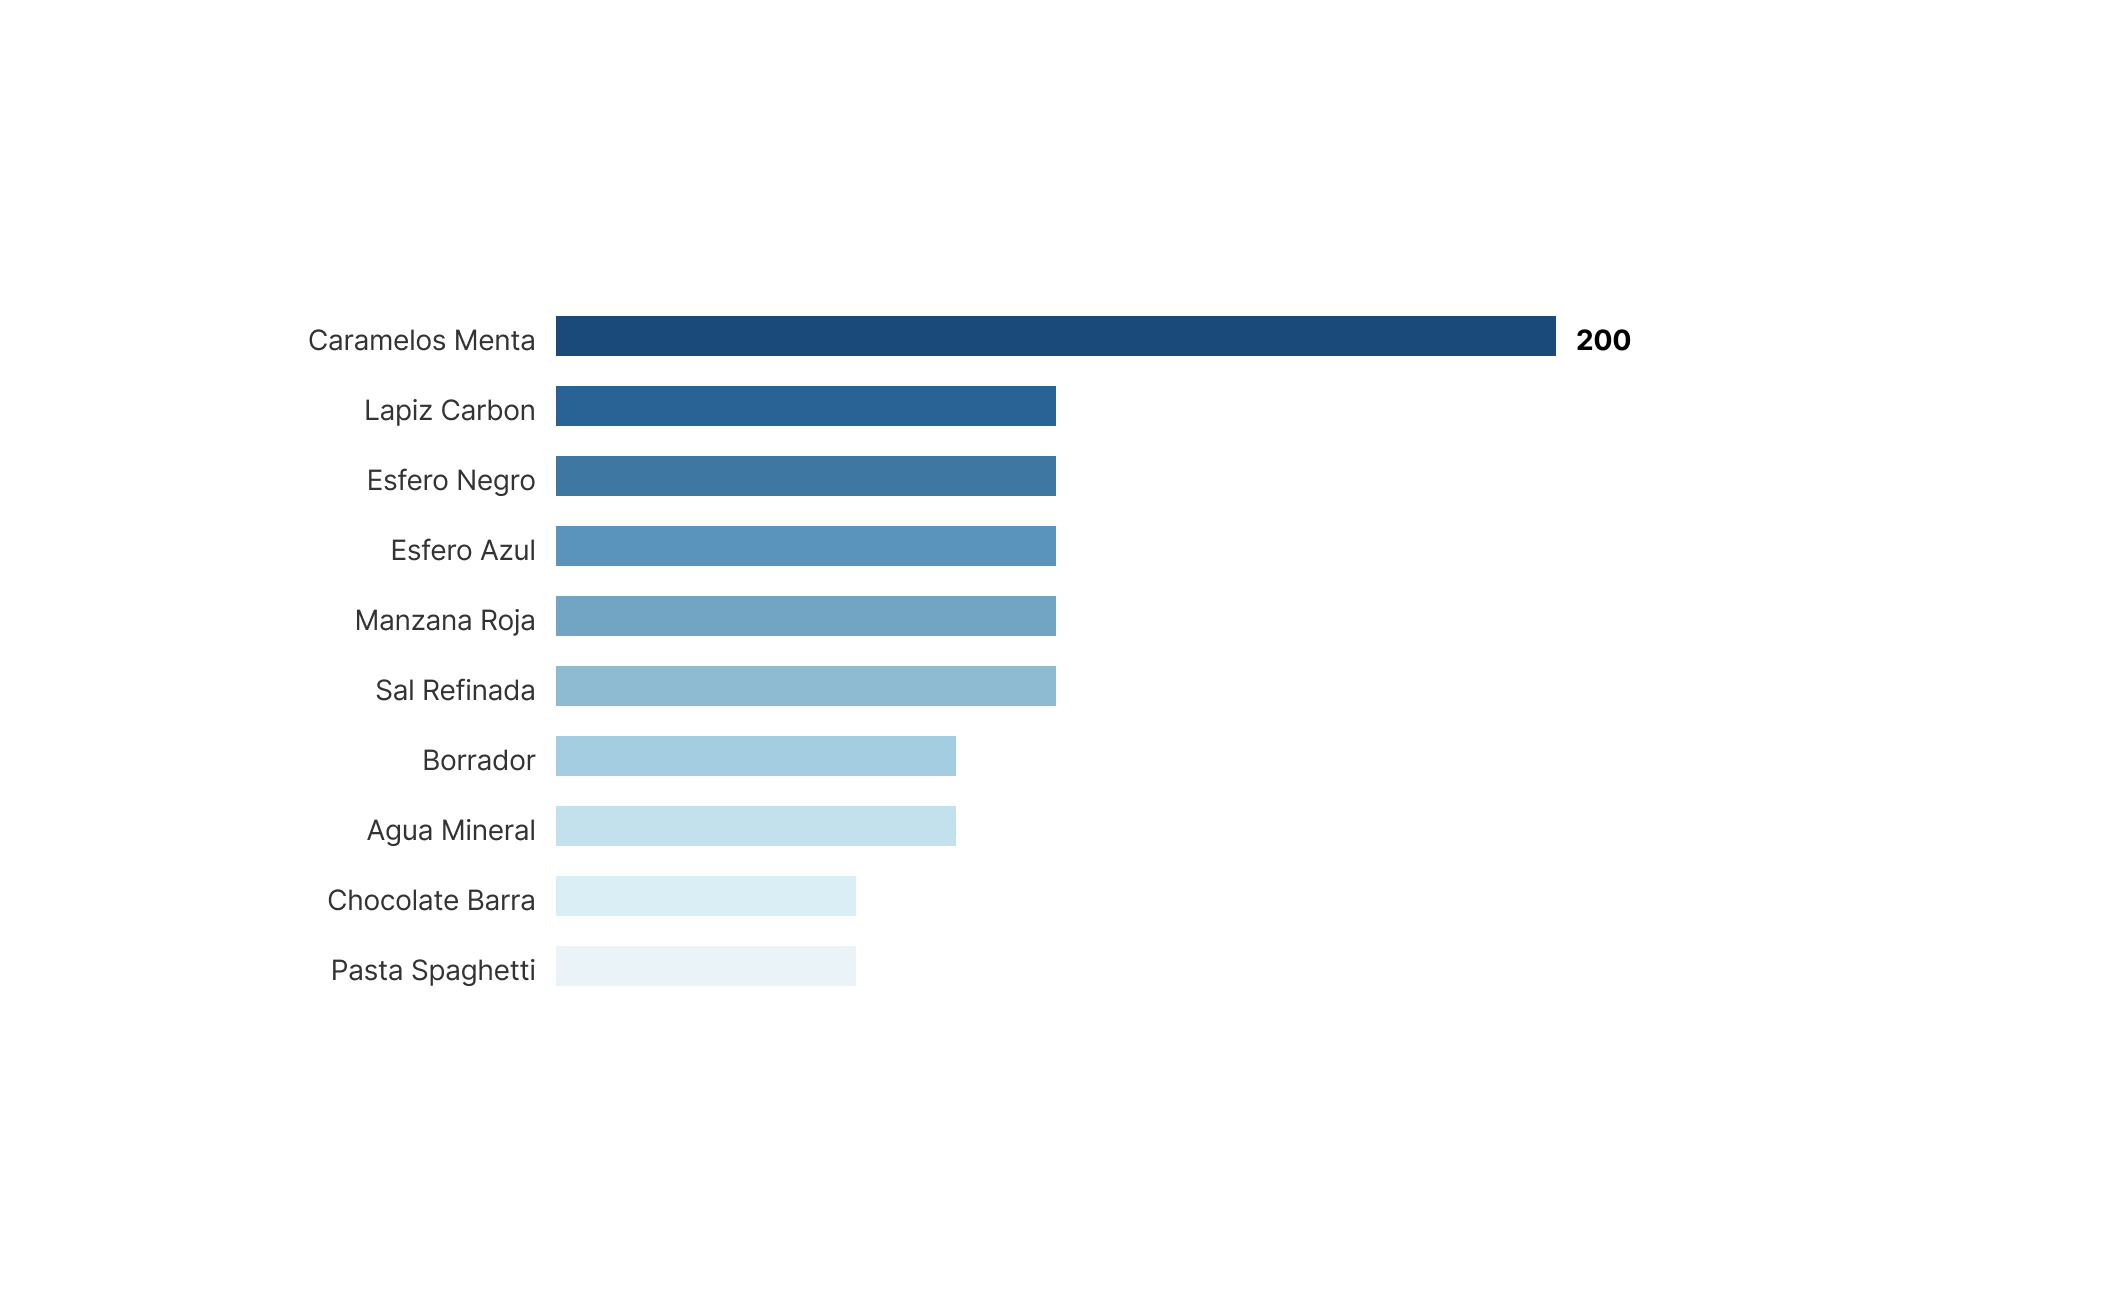

🛒 TABLA ANALÍTICA - KPI 2: TOP 10 PRODUCTOS CON MAYOR STOCK
         nombre categoria  precio  stock
Caramelos Menta    Dulces    0.05    200
   Lapiz Carbon Papeleria    0.30    100
   Esfero Negro Papeleria    0.40    100
    Esfero Azul Papeleria    0.40    100
   Manzana Roja    Frutas    0.50    100
   Sal Refinada   Viveres    0.45    100
       Borrador Papeleria    0.25     80
   Agua Mineral   Bebidas    0.60     80
Chocolate Barra    Dulces    0.85     60
Pasta Spaghetti   Viveres    0.75     60


/tmp/ipykernel_12079/2193019993.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafica = sns.barplot(


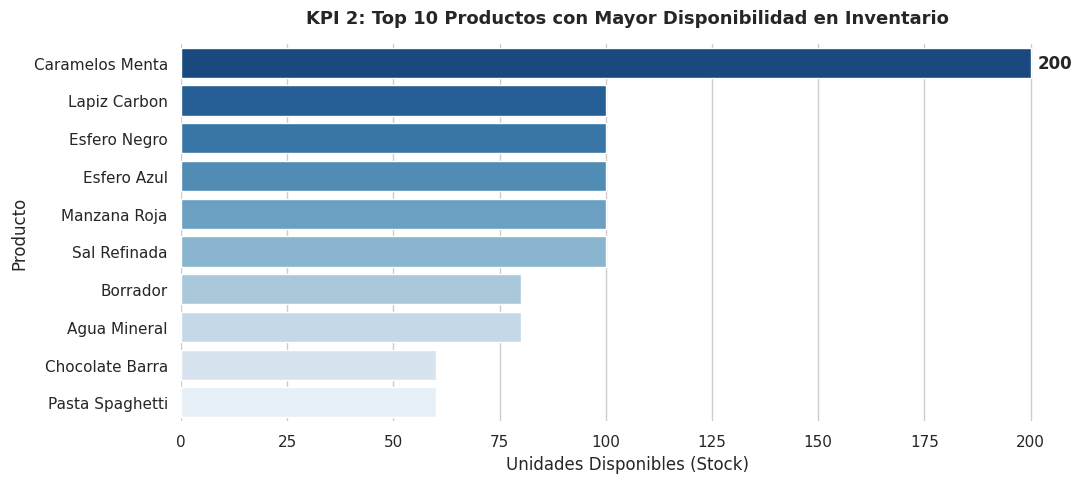

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Cargar el archivo de productos con su separador correcto
df_productos = pd.read_csv("productos.csv", sep=";")
df_productos.columns = df_productos.columns.str.strip()

# 2. Filtrar y ordenar los 10 productos con mayor rotación/stock disponible
productos_top2 = df_productos.sort_values(by="stock", ascending=False).head(10)

# 3. Imprimir la tabla limpia en la consola
print("=" * 65)
print("🛒 TABLA ANALÍTICA - KPI 2: TOP 10 PRODUCTOS CON MAYOR STOCK")
print("=" * 65)
print(
    productos_top2[["nombre", "categoria", "precio", "stock"]].to_string(
        index=False
    )
)
print("=" * 65)

# 4. Graficar para que quede hermoso en el deber
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")
grafica = sns.barplot(
    x="stock", y="nombre", data=productos_top2, palette="Blues_r"
)

# Añadir los números de stock al final de cada barra
plt.bar_label(grafica.containers[0], padding=5, fontweight="bold")

plt.title(
    "KPI 2: Top 10 Productos con Mayor Disponibilidad en Inventario",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Unidades Disponibles (Stock)")
plt.ylabel("Producto")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## KPI 3: Segmentación de Clientes por Volumen de Compra (Top 10 Clientes Estratégicos)

### Descripción Técnica:
Este módulo implementa un algoritmo de agregación relacional para identificar a los consumidores de mayor valor estratégico (*High-Value Customers*). Al consolidar el histórico de transacciones, permite mapear de forma unívoca a los compradores que más capital acumulado aportan al flujo de caja del negocio.

### Explicación Línea por Línea del Código:

* **`pd.read_csv("facturas.csv", sep=";")`**: Carga el dataset de facturación en memoria como un DataFrame de Pandas, aplicando un filtrado por el delimitador de punto y coma (`;`) para estructurar las variables de forma simétrica.
* **`df_facturas.columns.str.strip()`**: Elimina los espacios en blanco residuales o caracteres ocultos en los metadatos de las columnas, asegurando una llamada limpia a las series de datos en los procesos subsiguientes.
* **`df_facturas.groupby(["Cedula", "Cliente"])["Total"].sum()`**: Ejecuta una agrupación matricial mediante una clave compuesta (`"Cedula"` y `"Cliente"`). Esto previene colisiones o duplicidades en caso de que existan clientes homónimos. Posteriormente, aísla el vector `"Total"` y aplica una función de reducción por sumatoria acumulada por cada grupo.
* **`.reset_index()`**: Aplana la estructura jerárquica indexada resultante del `.groupby()`, transformándola nuevamente en un DataFrame bidimensional estándar listo para ser operado de forma lineal.
* **`.sort_values(by="Total", ascending=False).head(10)`**: Aplica un ordenamiento descendente tomando como pivote el monto total de dinero acumulado y realiza un truncamiento en los primeros 10 elementos, aislando así el "Top 10" requerido.
* **`.astype(str)`**: Realiza una conversión explícita de tipo de dato (*Casting*) sobre la serie numérica de las cédulas a tipo cadena. Esto evita que Matplotlib interprete las identidades numéricas como un eje continuo o use notación científica.
* **`df_clientes_kpi3["Cliente"] + " (" + df_clientes_kpi3["Cedula"] + ")"`**: Operación de concatenación de cadenas de texto a nivel vectorial. Consolida el nombre de la persona y su número de identificación en una sola columna lógica llamada `"Etiqueta_Cliente"`, sirviendo como un identificador de alta densidad informativa para el eje de la gráfica.
* **`df_clientes_kpi3[[...]].to_string(index=False)`**: Imprime una matriz puramente textual de las tres variables clave en la consola de Colab, removiendo los índices auto-incrementales de Pandas para una presentación ejecutiva limpia.
* **`sns.barplot(x="Total", y="Etiqueta_Cliente", data=..., palette="Greens_r")`**: Construye el diagrama de barras horizontales usando Seaborn. Los clientes de mayor aportación se posicionan en la parte superior debido a la paleta degradada inversa `"Greens_r"`, asociada psicológicamente al rendimiento financiero.
* **`for barra in grafica_cli.containers[0]:`**: Bucle iterativo que recorre cada uno de los rectángulos renderizados en la gráfica para extraer su anchura dinámica (`barra.get_width()`).
* **`plt.text(...)`**: Inyecta etiquetas de datos personalizadas directamente en las coordenadas del lienzo. Mediante un desplazamiento matemático relativo (`ancho + max * 0.01`), posiciona los valores de forma externa a la barra y les aplica una máscara tipográfica (`f"${ancho:,.2f}"`) para renderizarlos con formato de moneda estándar estadounidense (separador de miles por comas y dos decimales fijos).

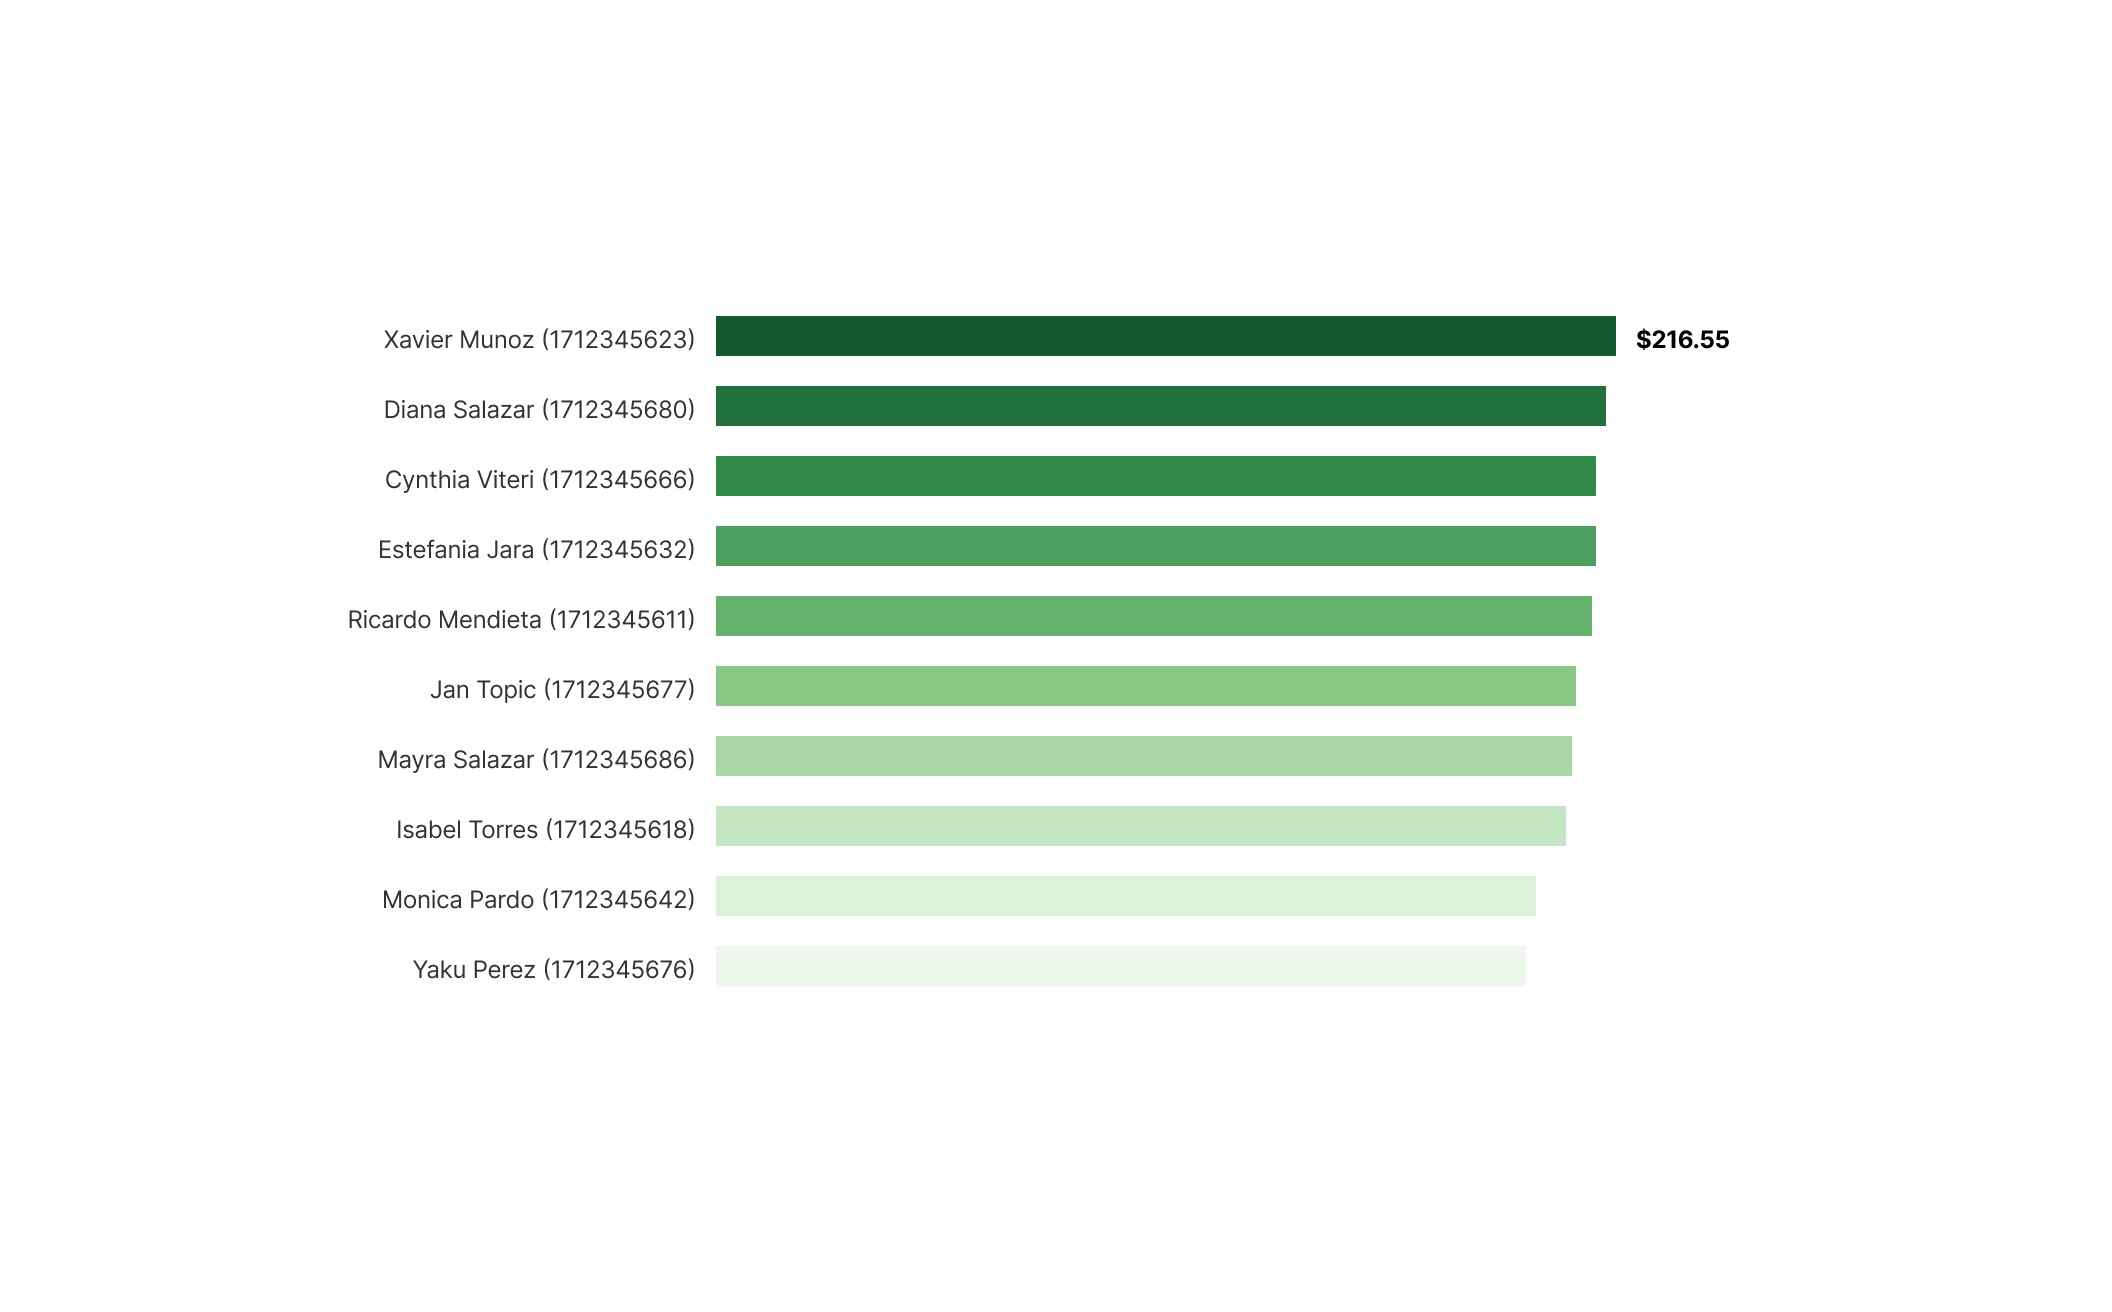

👥 TABLA ANALÍTICA - KPI 3: TOP 10 CLIENTES CON MAYOR VOLUMEN DE COMPRA
    Cedula          Cliente  Total
1712345623     Xavier Munoz 216.55
1712345680    Diana Salazar 214.75
1712345666   Cynthia Viteri 213.25
1712345632   Estefania Jara 212.80
1712345611 Ricardo Mendieta 212.65
1712345677        Jan Topic 210.20
1712345686    Mayra Salazar 209.45
1712345618    Isabel Torres 208.70
1712345642     Monica Pardo 202.40
1712345676       Yaku Perez 200.90


/tmp/ipykernel_12079/1052286053.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafica_cli = sns.barplot(


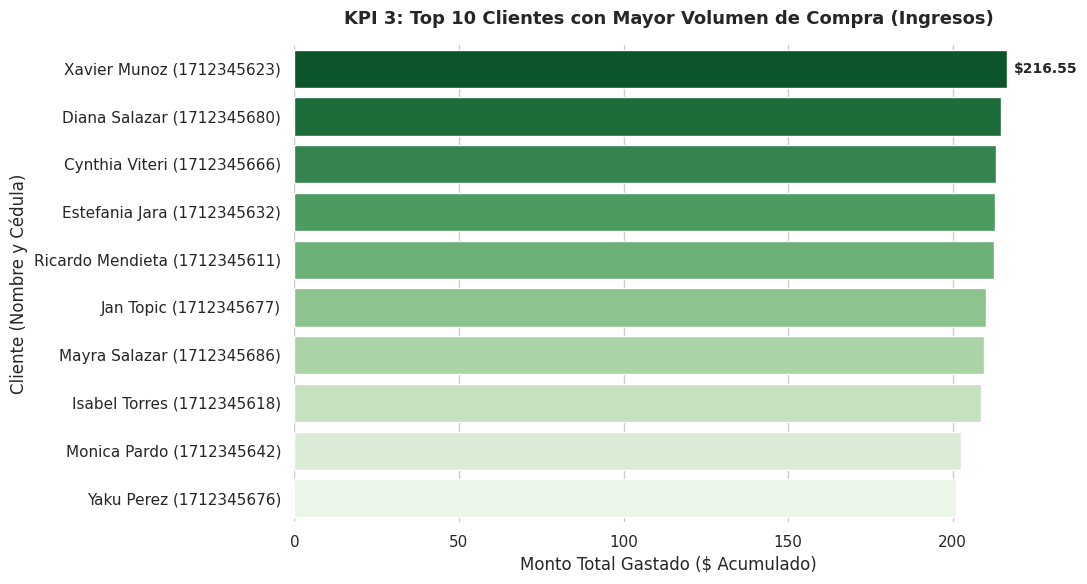

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Cargar el archivo de facturas con su separador correcto
df_facturas = pd.read_csv("facturas.csv", sep=";")
df_facturas.columns = df_facturas.columns.str.strip()

# 2. Agrupar y procesar los montos acumulados por cliente de forma segura
df_clientes_kpi3 = (
    df_facturas.groupby(["Cedula", "Cliente"])["Total"]
    .sum()
    .reset_index()
)
df_clientes_kpi3 = df_clientes_kpi3.sort_values(
    by="Total", ascending=False
).head(10)

# Asegurar que la cédula se vea bien como texto en la gráfica
df_clientes_kpi3["Cedula"] = df_clientes_kpi3["Cedula"].astype(str)
df_clientes_kpi3["Etiqueta_Cliente"] = (
    df_clientes_kpi3["Cliente"] + " (" + df_clientes_kpi3["Cedula"] + ")"
)

# 3. Imprimir la tabla analítica limpia en la consola
print("=" * 75)
print("👥 TABLA ANALÍTICA - KPI 3: TOP 10 CLIENTES CON MAYOR VOLUMEN DE COMPRA")
print("=" * 75)
print(
    df_clientes_kpi3[["Cedula", "Cliente", "Total"]].to_string(index=False)
)
print("=" * 75)

# 4. Graficar de forma elegante con tonos verdes de negocio
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")
grafica_cli = sns.barplot(
    x="Total", y="Etiqueta_Cliente", data=df_clientes_kpi3, palette="Greens_r"
)

# Añadir las etiquetas de dinero exactas al final de cada barra horizontal
for barra in grafica_cli.containers[0]:
    ancho = barra.get_width()
    plt.text(
        ancho + (df_clientes_kpi3["Total"].max() * 0.01),
        barra.get_y() + barra.get_height() / 2,
        f"${ancho:,.2f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

plt.title(
    "KPI 3: Top 10 Clientes con Mayor Volumen de Compra (Ingresos)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Monto Total Gastado ($ Acumulado)")
plt.ylabel("Cliente (Nombre y Cédula)")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 4: Validación de Atributos de Información e Interpretación Gerencial

## 4.1 Matriz de Atributos de Valor

| 📋 Atributo de Valor | 💰 KPI 1: Ventas Totales | 🛒 KPI 2: Mayor Stock | 👥 KPI 3: Clientes Top | 🛠️ Validación en nuestra Solución (MIS) |
| :--- | :---: | :---: | :---: | :--- |
| **Simplicidad** | Sí | Sí | Sí | El entorno gráfico suprime ruido visual cartesiano mediante `sns.despine()`. El KPI 1 usa una tarjeta minimalista y los KPIs 2 y 3 emplean barras horizontales que destacan únicamente magnitudes críticas de un solo vistazo. |
| **Oportunidad** *(Timeliness)* | Sí | Sí | Sí | Las rutinas de filtrado y agregación vectorial en Pandas se ejecutan en milisegundos en la infraestructura de Colab, permitiendo un procesamiento inmediato al cargar los archivos transaccionales (`.csv`) del TPS. |
| **Accesibilidad** | Sí | Sí | Sí | Diseño intuitivo para usuarios no técnicos. La inyección de etiquetas automáticas de datos (`plt.bar_label` y `plt.text`) y el formato monetario explícito eliminan escalas ambiguas o sobrecargas informativas. |

4.2 Documentación de Interpretación Gerencial

💰 Interpretación Gerencial - KPI 1 (Ventas Totales Generales)
Si este indicador clave de rendimiento muestra un comportamiento por debajo del umbral presupuestario o de las metas proyectadas para el periodo actual, la acción correctiva o estratégica que la gerencia debe ejecutar de inmediato es congelar de forma temporal los gastos operativos no esenciales, auditar la elasticidad de los precios de los productos líderes frente a la competencia, y paralelamente estructurar campañas de marketing de conversión rápida o promociones cruzadas en el punto de venta para estimular la demanda y proteger el flujo de caja operativo del negocio.


🛒 Interpretación Gerencial - KPI 2 (Top 10 Productos con Mayor Stock)
Si este indicador clave de rendimiento muestra un comportamiento de acumulación excesiva o una densidad física desproporcionada en almacén, la acción correctiva o estratégica que la gerencia debe ejecutar de inmediato es congelar de forma automática las órdenes de reabastecimiento y compras hacia proveedores para estas líneas de producto específicas, coordinando simultáneamente con el equipo comercial la salida forzosa de este inventario inmovilizado mediante estrategias de merchandising, combos atados o descuentos por volumen para evitar la obsolescencia y liberar capital de trabajo retenido.

👥 Interpretación Gerencial - KPI 3 (Top 10 Clientes con Mayor Volumen de Compra)
Si este indicador clave de rendimiento muestra un comportamiento de acentuada contracción o una caída significativa en los montos de compra acumulados por parte de nuestros compradores principales, la acción correctiva o estratégica que la gerencia debe ejecutar de inmediato es desplegar al departamento de atención al cliente VIP para contactar directamente a estos usuarios estratégicos, diagnosticar posibles fallas en la cadena de servicio o suministro, contrarrestar las ofertas de la competencia y diseñar un plan personalizado de incentivos, bonificaciones o tarifas preferenciales que asegure su retención y lealtad a largo plazo.